<a href="https://colab.research.google.com/github/Lindaoctaviani7/PCVK_TI3B_Linda-Octaviani_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
PRAKTIKUM

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import library

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob, os, math
from math import log10, sqrt

Transformasi Linier Brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


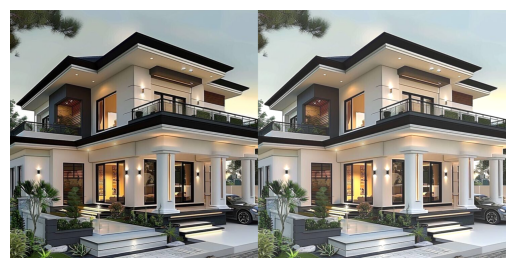

In [53]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuai dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/house.jpg')

# Menggunakan fungsi cv.convertScaleAbs untuk penyesuaian kecerahan yang efisien dan benar.
# Fungsi ini secara otomatis menangani tipe data dan clipping, menghindari overflow warning.
brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))

# Menggunakan plt.imshow untuk menampilkan citra, dengan konversi BGR ke RGB
plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

**Tugas Praktikum**

1. Inverse Citra

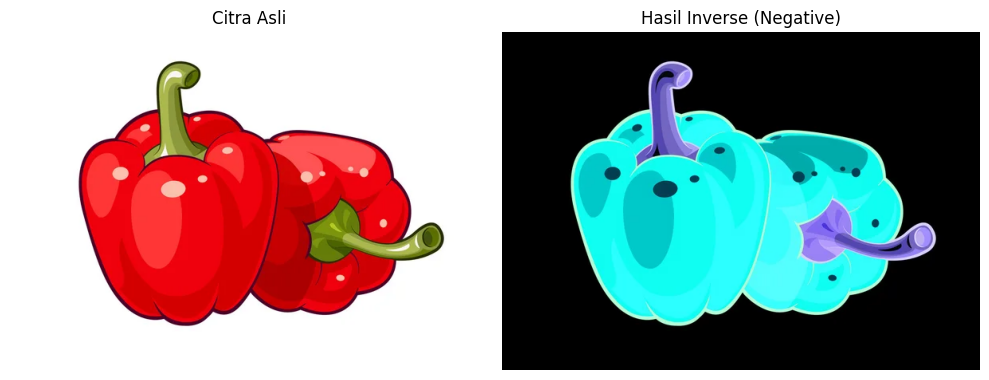

In [29]:
def inverse_image(image):
    """Inverse / negative citra: g = 255 - f (berlaku untuk tiap channel R, G, B)"""
    return 255 - image

peppers = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/paprika1.jpg')
inv_peppers = inverse_image(peppers)

show_pair(peppers, inv_peppers, 'Citra Asli', 'Hasil Inverse (Negative)')

2. Transformasi Contrast

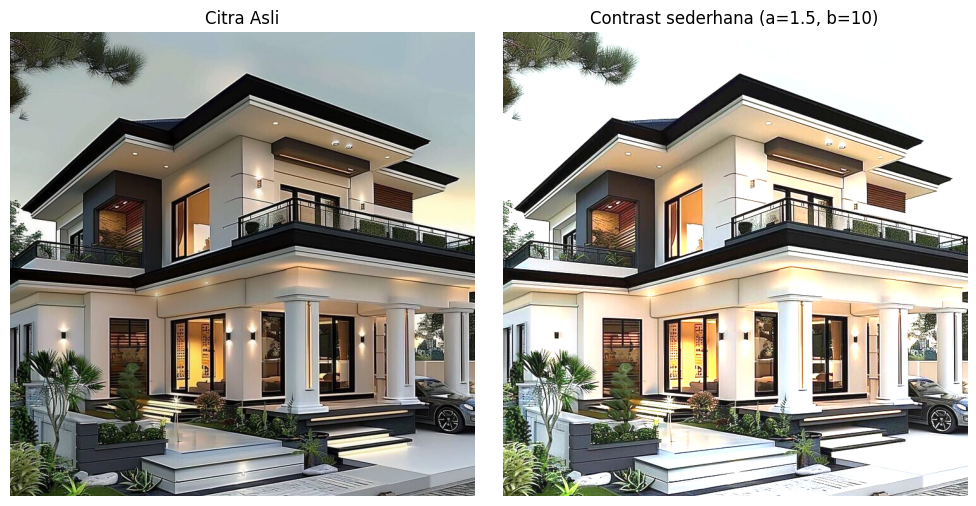

In [30]:
def contrast_simple(image, a, b=0):
    """Transformasi contrast versi sederhana: g(x,y) = a*f(x,y) + b"""
    result = np.clip(image.astype(np.float64) * a + b, 0, 255).astype(np.uint8)
    return result

sunset = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/house.jpg')
kecerahan2, kontras2 = 10, 1.5
contrast_img2 = contrast_simple(sunset, kontras2, kecerahan2)

show_pair(sunset, contrast_img2, 'Citra Asli',
          f'Contrast sederhana (a={kontras2}, b={kecerahan2})')


3. Transformasi Logarithmic Brightness

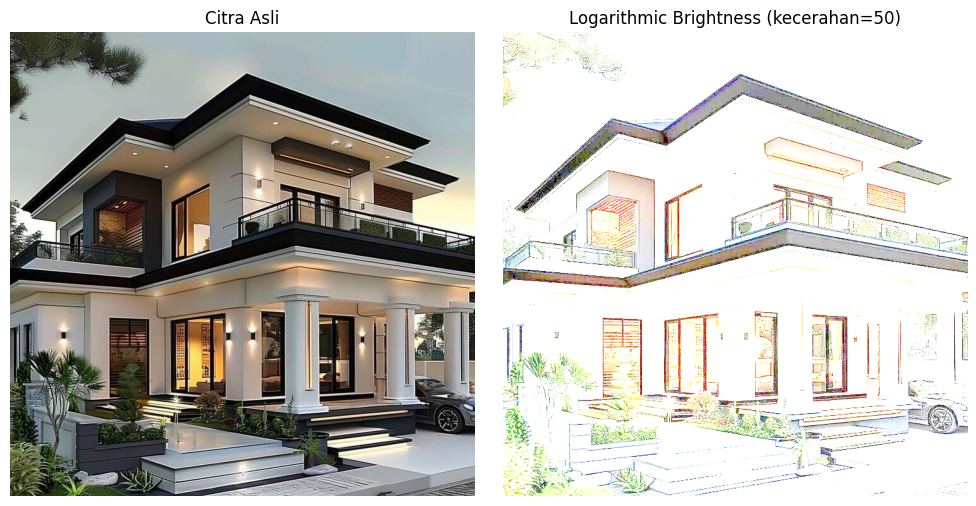

In [64]:
def log_brightness(image, brightness_level=50):
    """Transformasi Logarithmic Brightness: s = c*log(1+r), c dihitung otomatis
    agar nilai maksimum output tetap 255, kemudian digeser sesuai brightness_level
    supaya efeknya konsisten dengan input pengguna (mirip skala pada modul)."""
    img = image.astype(np.float64)
    c = 255.0 / np.log(1 + 255.0)
    log_img = c * np.log(1 + img)
    # brightness_level menambah bobot penguatan highlight bagian gelap
    gain = 1 + (brightness_level / 100.0)
    result = np.clip(log_img * gain, 0, 255).astype(np.uint8)
    return result

houses2 = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/house.jpg')
nilai_kecerahan = 50
log_img = log_brightness(houses2, nilai_kecerahan)

show_pair(houses2, log_img, 'Citra Asli', f'Logarithmic Brightness (kecerahan={nilai_kecerahan})')

4. Transformasi Grayscale (Averaging, Lightness, Luminance)

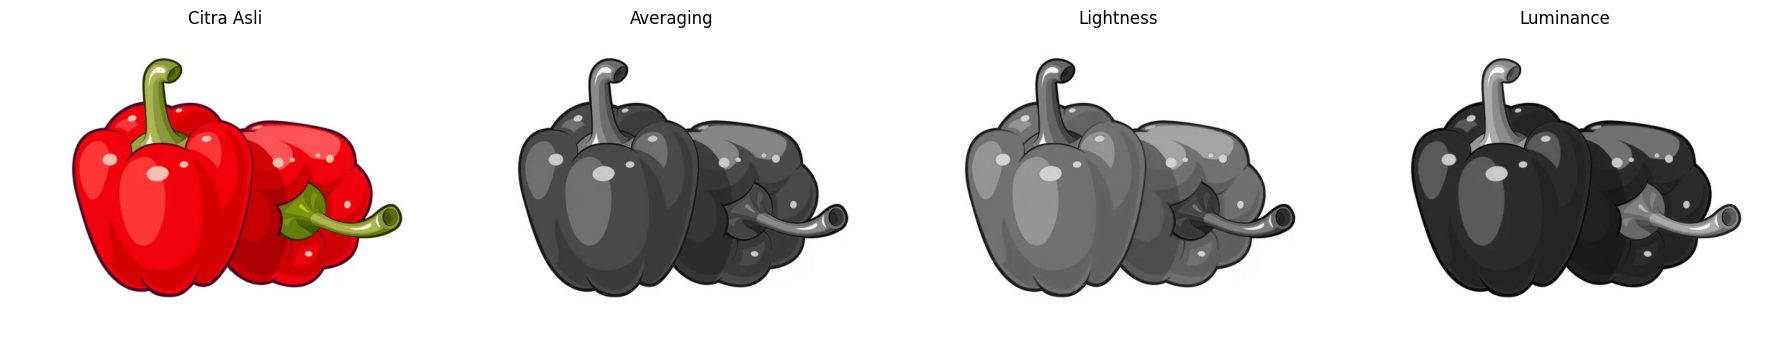

In [32]:
def grayscale_average(image):
    """Grayscale_avg = (R+G+B)/3"""
    b, g, r = cv.split(image.astype(np.float64))
    gray = (r + g + b) / 3.0
    return np.clip(gray, 0, 255).astype(np.uint8)

def grayscale_lightness(image):
    """Grayscale_Lightness = (max[R,G,B] + min[R,G,B]) / 2"""
    img = image.astype(np.float64)
    max_c = np.max(img, axis=2)
    min_c = np.min(img, axis=2)
    gray = (max_c + min_c) / 2.0
    return np.clip(gray, 0, 255).astype(np.uint8)

def grayscale_luminance(image):
    """Grayscale_Luminance = 0.21R + 0.72G + 0.07B"""
    b, g, r = cv.split(image.astype(np.float64))
    gray = 0.21 * r + 0.72 * g + 0.07 * b
    return np.clip(gray, 0, 255).astype(np.uint8)

peppers2 = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/paprika1.jpg')
gray_avg = grayscale_average(peppers2)
gray_light = grayscale_lightness(peppers2)
gray_lum = grayscale_luminance(peppers2)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv.cvtColor(peppers2, cv.COLOR_BGR2RGB)); axes[0].set_title('Citra Asli')
axes[1].imshow(gray_avg, cmap='gray'); axes[1].set_title('Averaging')
axes[2].imshow(gray_light, cmap='gray'); axes[2].set_title('Lightness')
axes[3].imshow(gray_lum, cmap='gray'); axes[3].set_title('Luminance')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

5. Menampilkan Warna Tertentu, Selain Itu Menjadi Grayscale

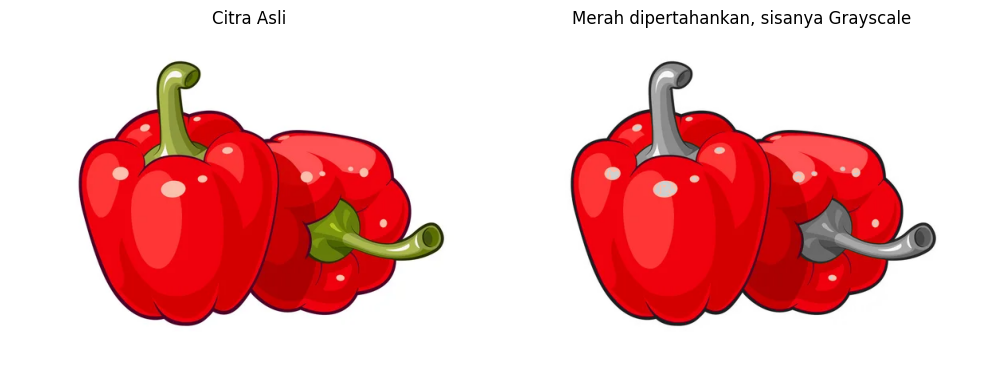

In [33]:
def color_selective_grayscale(image, hue_range=((0,10),(170,180)), sat_min=80, val_min=50):
    """Pertahankan warna tertentu (default: merah) berdasarkan rentang Hue HSV,
    dan ubah bagian lain menjadi grayscale."""
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
    h, s, v = cv.split(hsv)

    mask = np.zeros(h.shape, dtype=np.uint8)
    for (low, high) in hue_range:
        mask |= ((h >= low) & (h <= high)).astype(np.uint8) * 255
    mask &= ((s >= sat_min) & (v >= val_min)).astype(np.uint8) * 255

    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

    mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
    result = np.where(mask_3ch == 255, image, gray_3ch)
    return result, mask

peppers3 = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/paprika1.jpg')
result_red, mask_red = color_selective_grayscale(peppers3)

show_pair(peppers3, result_red, 'Citra Asli', 'Merah dipertahankan, sisanya Grayscale')

6. Gamma Correction

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5
Error, not a number


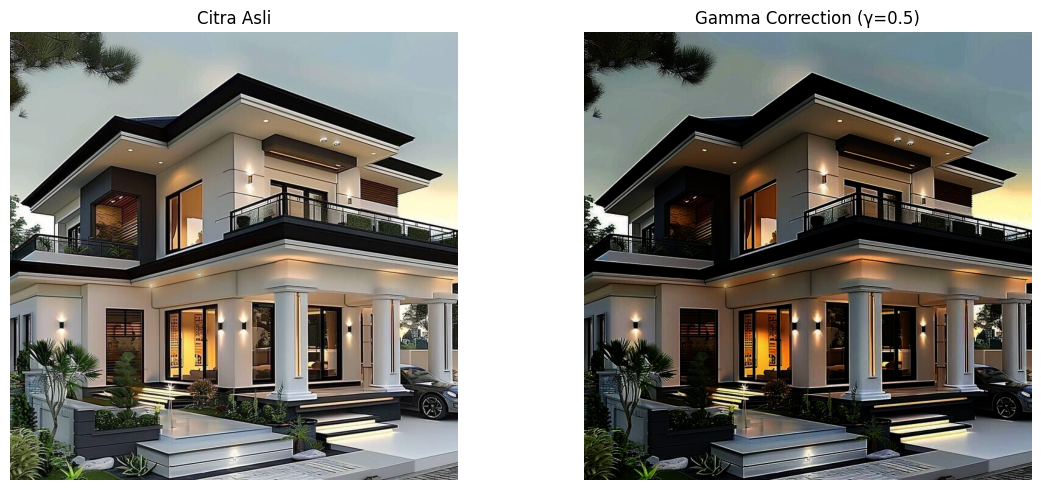

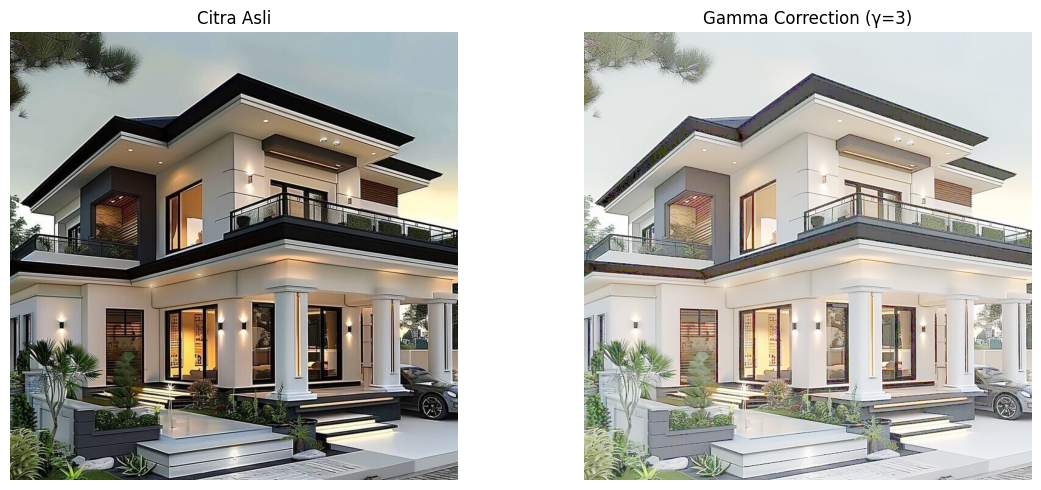

In [58]:
def gamma_correction(image, gamma):
    """Gamma Correction: I' = 255 * (I/255)^(1/gamma)"""
    if gamma <= 0:
        raise ValueError('Nilai gamma harus > 0')
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv.LUT(image, table)

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

houses3 = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/house.jpg')
gamma_img = gamma_correction(houses3, gamma_val)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv.cvtColor(houses3, cv.COLOR_BGR2RGB)); axes[0].set_title('Citra Asli')
axes[1].imshow(cv.cvtColor(gamma_img, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Gamma Correction (γ={gamma_val})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# Contoh tambahan dengan gamma = 3 (mencerahkan lebih agresif jika < 1, menggelapkan jika > 1)
gamma_val2 = 3
gamma_img2 = gamma_correction(houses3, gamma_val2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv.cvtColor(houses3, cv.COLOR_BGR2RGB)); axes[0].set_title('Citra Asli')
axes[1].imshow(cv.cvtColor(gamma_img2, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Gamma Correction (γ={gamma_val2})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

7. Simulasi Image Depth

 Simulasi Image Depth 
----------------------------------
Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


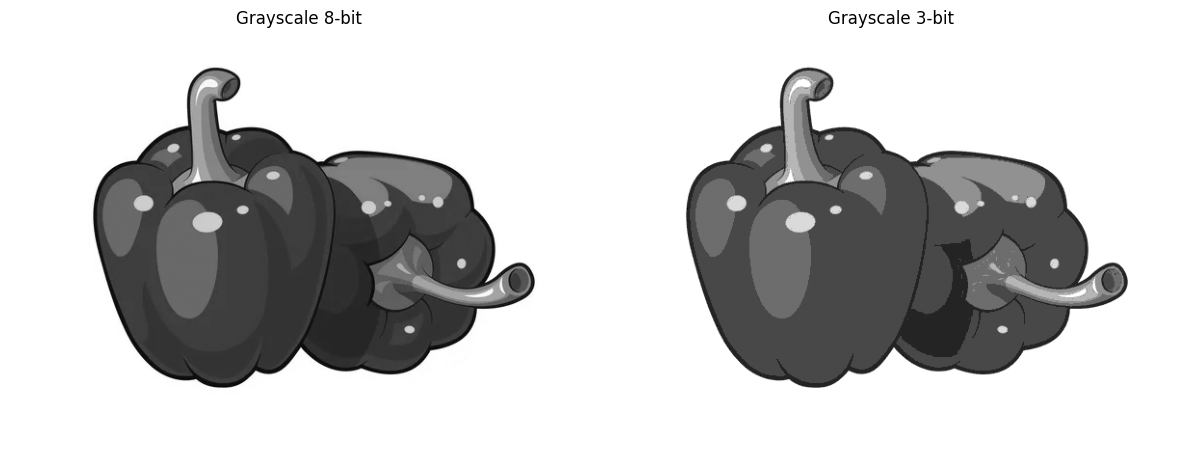

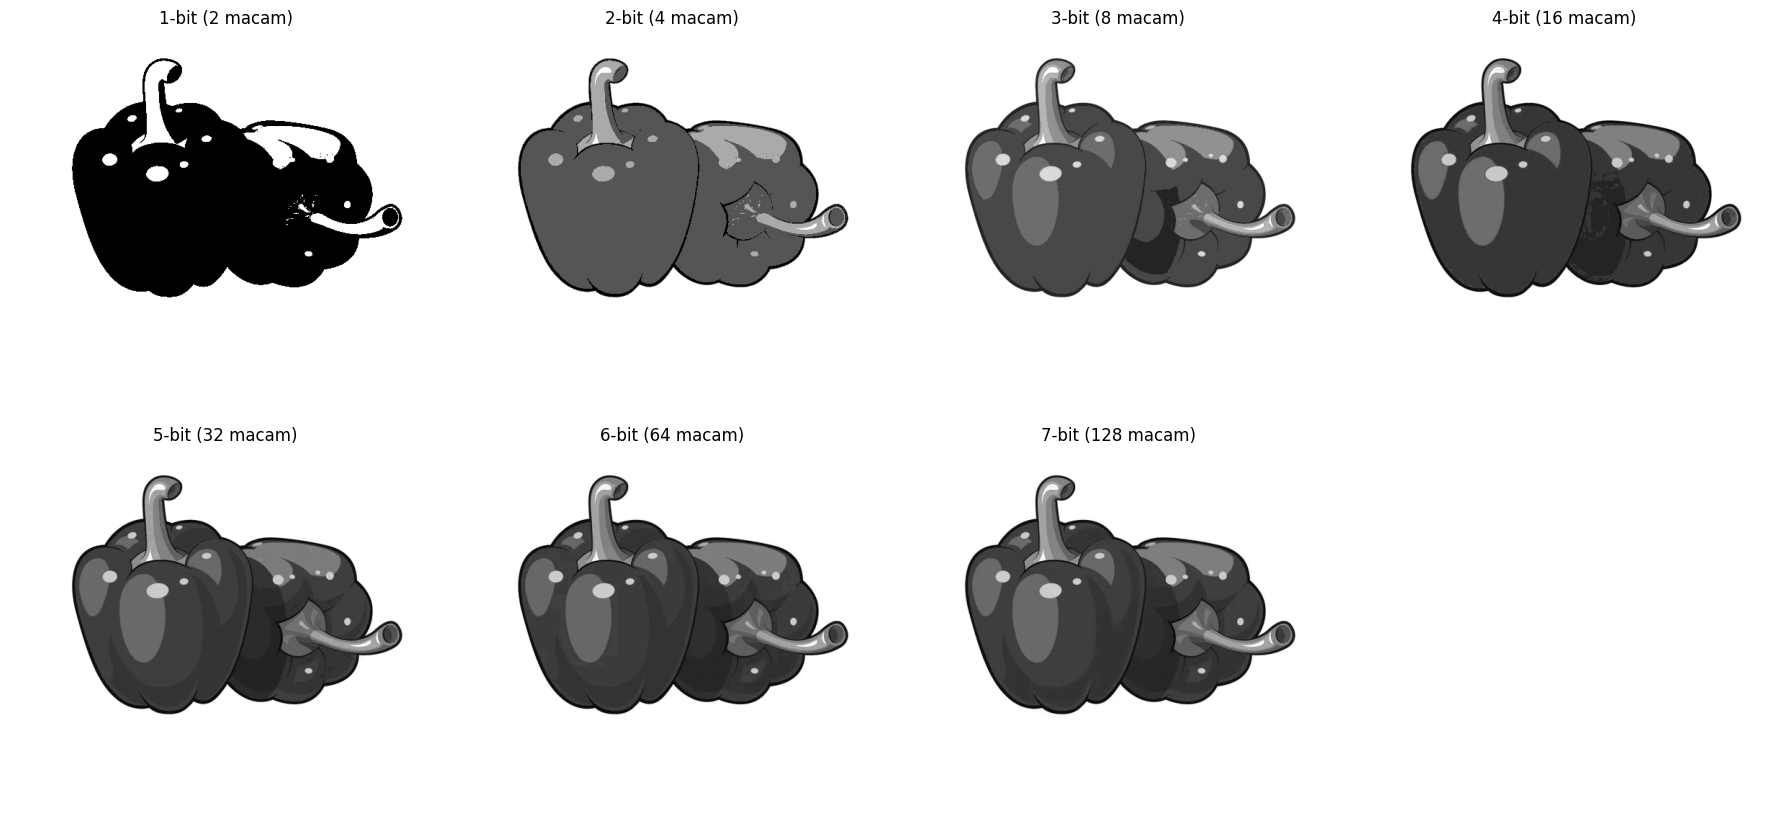

In [62]:
def simulate_bit_depth(image_gray, bit_depth):
    """Simulasi kuantisasi citra grayscale ke n-bit (1-8 bit)"""
    level = 255.0 / (pow(2, bit_depth) - 1)
    depth_image = np.round(image_gray.astype(np.float64) / level) * level
    depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)
    return depth_image

original_gray = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/paprika1.jpg', cv.IMREAD_GRAYSCALE)

print(' Simulasi Image Depth ')
print('----------------------------------')
try:
    # Mengambil input dari pengguna untuk bit_depth_tujuan
    bit_depth_tujuan = int(input('Masukkan bit depth tujuan (1-8): '))
    if not (1 <= bit_depth_tujuan <= 8):
        raise ValueError("Bit depth harus antara 1 dan 8.")
except ValueError as e:
    print(f'Error: {e}. Menggunakan nilai default 3 bit.')
    bit_depth_tujuan = 3 # Nilai default jika input tidak valid

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth_tujuan} bit')
print(f'Jumlah level    : {int(pow(2, bit_depth_tujuan))}')

depth_image = simulate_bit_depth(original_gray, bit_depth_tujuan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_gray, cmap='gray'); axes[0].set_title('Grayscale 8-bit')
axes[1].imshow(depth_image, cmap='gray'); axes[1].set_title(f'Grayscale {bit_depth_tujuan}-bit')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# Demonstrasi untuk beberapa nilai bit depth sekaligus
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for idx, bd in enumerate(range(1, 8)):
    r, c = divmod(idx, 4)
    axes[r, c].imshow(simulate_bit_depth(original_gray, bd), cmap='gray')
    axes[r, c].set_title(f'{bd}-bit ({int(pow(2,bd))} macam)')
    axes[r, c].axis('off')
axes[1, 3].axis('off')
plt.tight_layout(); plt.show()

8. Average Denoising & PSNR

Jumlah citra noise terbaca: 100


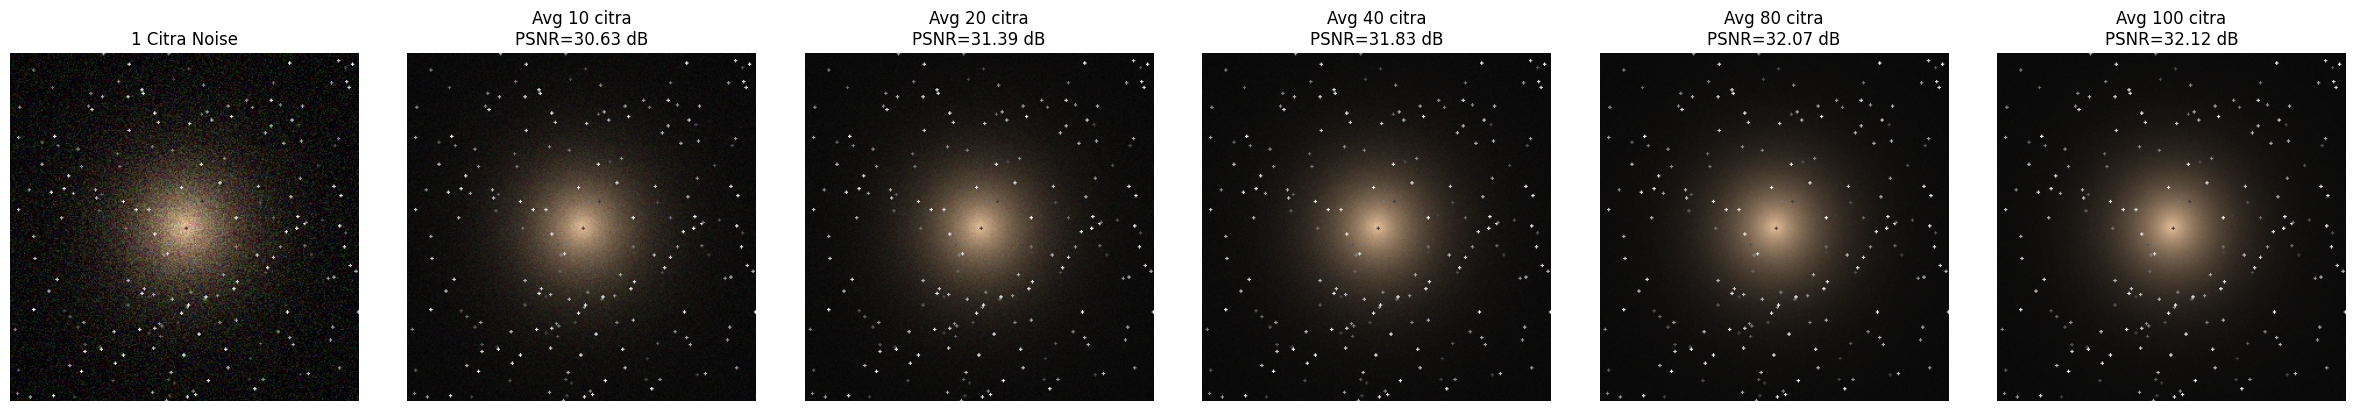

No  Jumlah Citra   Nilai PSNR (dB)
1   10             30.63          
2   20             31.39          
3   40             31.83          
4   80             32.07          
5   100            32.12          


In [44]:
def PSNR(img1, img2):
    """Menghitung PSNR antara dua citra (rumus sesuai modul)"""
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

def average_denoise(images, n):
    """Merata-ratakan n citra pertama dari kumpulan citra bernoise"""
    stack = np.stack([im.astype(np.float64) for im in images[:n]], axis=0)
    avg = np.mean(stack, axis=0)
    return np.clip(avg, 0, 255).astype(np.uint8)

original_galaxy = cv.imread('images/galaxy.jpg')
cv_img = []
for fpath in sorted(glob.glob('images/noises/*.jpg')):
    n = cv.imread(fpath)
    cv_img.append(n)
print(f'Jumlah citra noise terbaca: {len(cv_img)}')

jumlah_list = [10, 20, 40, 80, 100]
hasil_tabel = []

fig, axes = plt.subplots(1, len(jumlah_list) + 1, figsize=(4 * (len(jumlah_list)+1), 4))
axes[0].imshow(cv.cvtColor(cv_img[0], cv.COLOR_BGR2RGB)); axes[0].set_title('1 Citra Noise')
axes[0].axis('off')

for i, n in enumerate(jumlah_list, start=1):
    denoised = average_denoise(cv_img, n)
    psnr_val = PSNR(original_galaxy, denoised)
    hasil_tabel.append((n, psnr_val))
    axes[i].imshow(cv.cvtColor(denoised, cv.COLOR_BGR2RGB))
    axes[i].set_title(f'Avg {n} citra\nPSNR={psnr_val:.2f} dB')
    axes[i].axis('off')
plt.tight_layout(); plt.show()

print(f"{'No':<4}{'Jumlah Citra':<15}{'Nilai PSNR (dB)':<15}")
for idx, (n, p) in enumerate(hasil_tabel, start=1):
    print(f"{idx:<4}{n:<15}{p:<15.2f}")

Analisis:
Berdasarkan tabel PSNR di atas, semakin banyak jumlah citra yang di-average, nilai PSNR
cenderung meningkat karena noise acak (Gaussian) saling meniadakan ketika dirata-rata
(variansi noise turun sebanding dengan 1/N). Namun, peningkatan PSNR tidak linear,
kenaikan PSNR paling signifikan terjadi pada rentang jumlah citra kecil (misalnya dari 10 ke 20 atau ke 40),
sedangkan pada jumlah citra besar (misalnya dari 80 ke 100) peningkatannya mulai melandai/kurang signifikan,
karena penurunan noise mengikuti hukum akar (∝ 1/√N), sehingga menambah lebih banyak citra memberikan
manfaat yang semakin kecil (*diminishing returns*). Kesimpulannya untuk efisiensi, tidak perlu
selalu menggunakan jumlah citra sebanyak mungkin cukup gunakan jumlah citra secukupnya
hingga kualitas (PSNR) dianggap memadai untuk kebutuhan aplikasi.


9. Image Masking (Operator Logika)

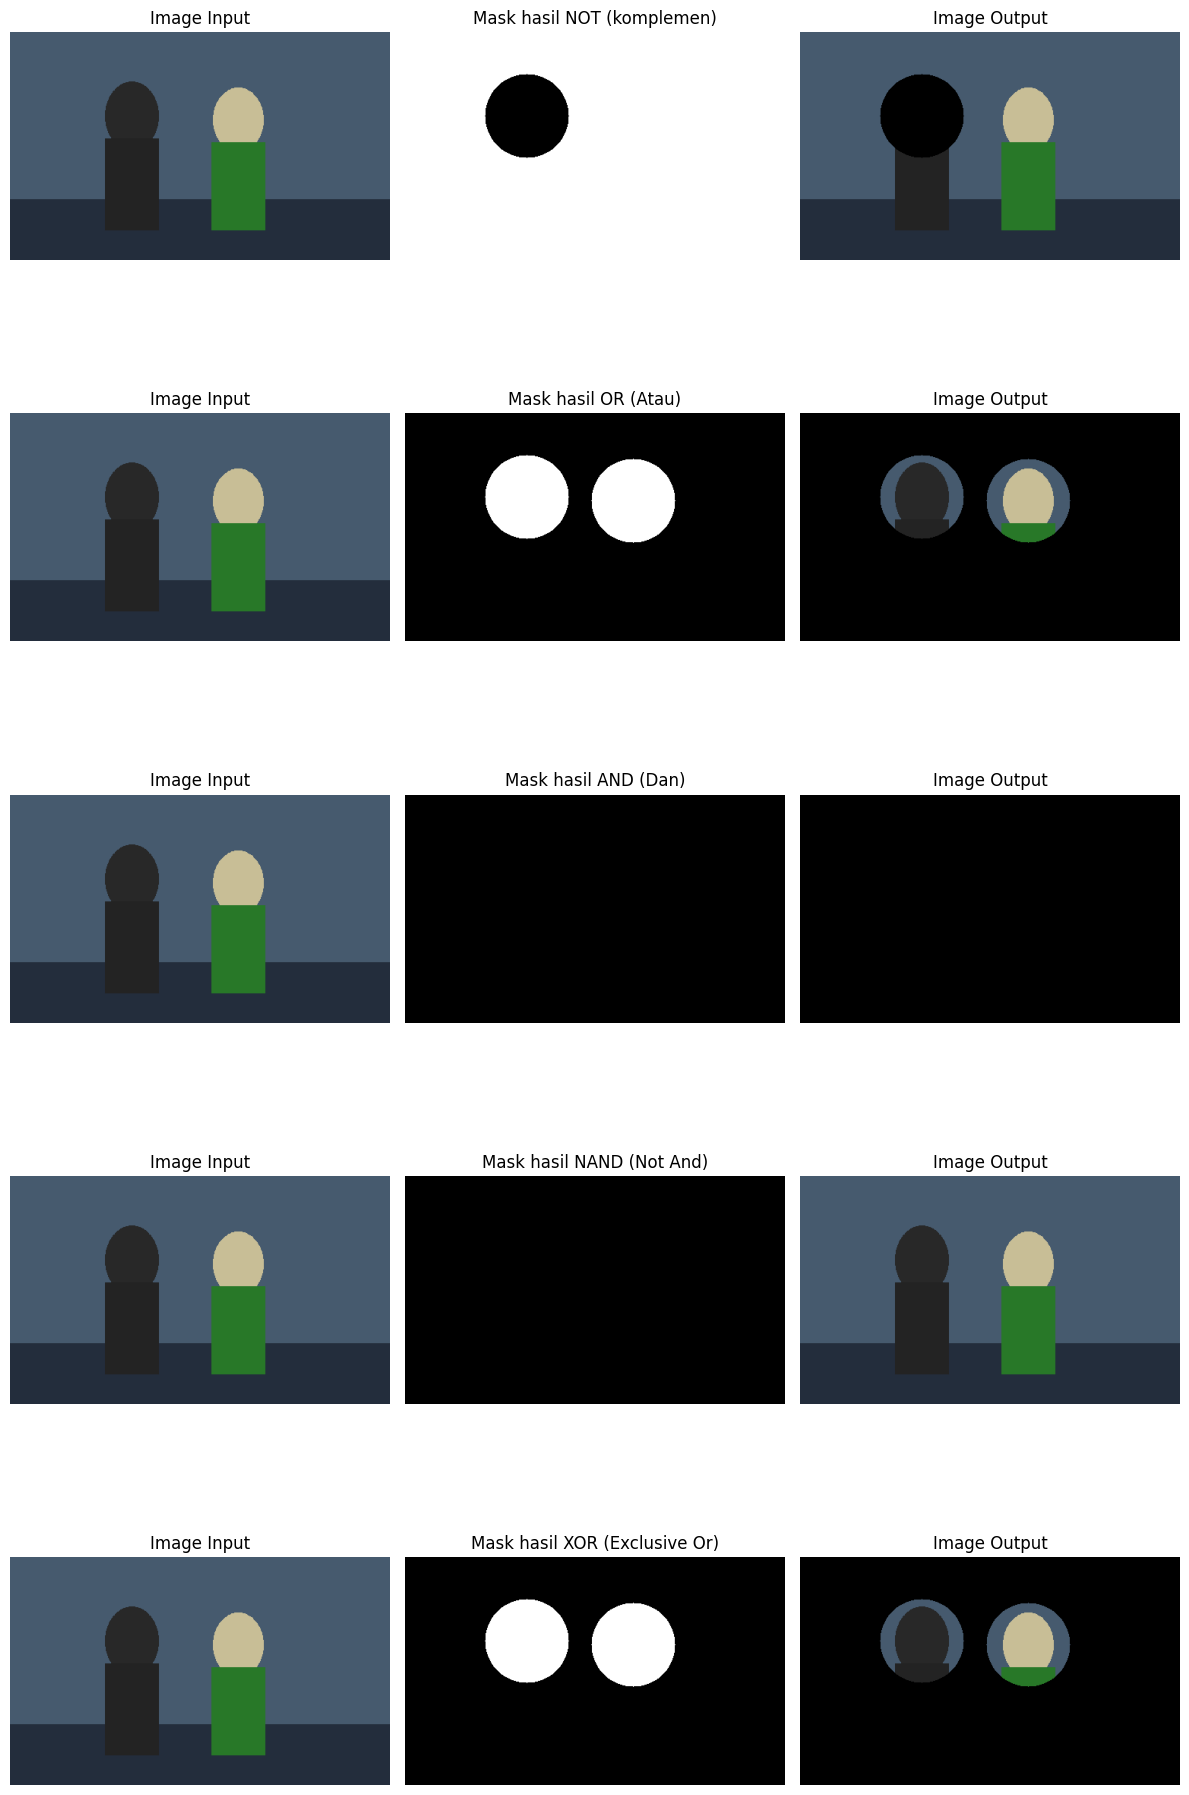

In [50]:
couple = cv.imread('images/couple.tiff')

# Buat mask lingkaran (region A) dan mask kedua (region B) untuk operasi logika
mask_A = np.zeros(couple.shape[:2], dtype=np.uint8)
cv.circle(mask_A, (160, 110), 55, 255, -1)

mask_B = np.zeros(couple.shape[:2], dtype=np.uint8)
cv.circle(mask_B, (300, 115), 55, 255, -1)

not_A   = cv.bitwise_not(mask_A)
or_AB   = cv.bitwise_or(mask_A, mask_B)
and_AB  = cv.bitwise_and(mask_A, mask_B)          # AND(A,B) -> tidak overlap = hitam semua
and_AB_disjoint_demo = cv.bitwise_and(mask_A, or_AB)  # demonstrasi AND yang overlap sebagian
nand_AB = cv.bitwise_not(or_AB)                    # NAND sederhana = NOT(OR) untuk ilustrasi; NAND asli = NOT(AND)
nand_AB_real = cv.bitwise_not(and_AB)
xor_AB  = cv.bitwise_xor(mask_A, mask_B)

def apply_mask(image, mask):
    return cv.bitwise_and(image, image, mask=mask)

results = {
    'NOT (komplemen)': not_A,
    'OR (Atau)': or_AB,
    'AND (Dan)': and_AB,
    'NAND (Not And)': nand_AB_real,
    'XOR (Exclusive Or)': xor_AB,
}

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
for row, (name, mask) in enumerate(results.items()):
    masked_img = apply_mask(couple, mask)
    axes[row, 0].imshow(cv.cvtColor(couple, cv.COLOR_BGR2RGB)); axes[row, 0].set_title('Image Input'); axes[row, 0].axis('off')
    axes[row, 1].imshow(mask, cmap='gray'); axes[row, 1].set_title(f'Mask hasil {name}'); axes[row, 1].axis('off')
    axes[row, 2].imshow(cv.cvtColor(masked_img, cv.COLOR_BGR2RGB)); axes[row, 2].set_title('Image Output'); axes[row, 2].axis('off')
plt.tight_layout(); plt.show()

Analisis hasil masking:

- NOT (komplemen): membalik area mask, sehingga foreground menjadi background dan sebaliknya.
- OR: menggabungkan region A dan B, sehingga menampilkan gabungan keduanya (union).
- AND: hanya menampilkan irisan A dan B. Jika keduanya tidak bertampalan, hasilnya kosong (hitam).
- NAND: kebalikan AND, yaitu menampilkan semua area kecuali irisan A dan B.
- XOR: menampilkan area yang hanya dimiliki salah satu A atau B, bukan keduanya.

10. Foto Malam Hari (Perbaikan Detail Gelap)
Metode yang dipilih yaitu Gamma Correction (γ < 1) karena mampu mengangkat detail pada
area gelap secara non-linear tanpa membuat area terang menjadi over-exposed / clipping,
berbeda dengan Linear Brightness yang berisiko membuat area terang langsung ter-*truncate*
menjadi putih polos (detail hilang permanen).


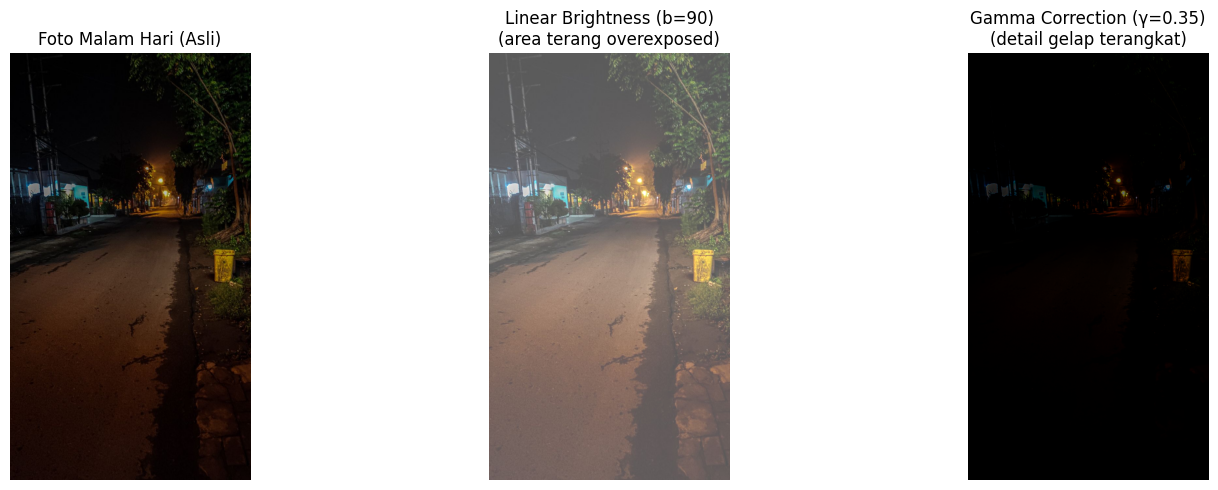

In [63]:
night_photo = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/malam.jpg')

gamma_night = 0.35   # gamma < 1 -> mencerahkan area gelap secara proporsional
enhanced_night = gamma_correction(night_photo, gamma_night)

# Sebagai pembanding, tunjukkan juga hasil Linear Brightness pada nilai brightness besar
linear_night = linear_brightness(night_photo, 90)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv.cvtColor(night_photo, cv.COLOR_BGR2RGB)); axes[0].set_title('Foto Malam Hari (Asli)')
axes[1].imshow(cv.cvtColor(linear_night, cv.COLOR_BGR2RGB)); axes[1].set_title('Linear Brightness (b=90)\n(area terang overexposed)')
axes[2].imshow(cv.cvtColor(enhanced_night, cv.COLOR_BGR2RGB)); axes[2].set_title(f'Gamma Correction (γ={gamma_night})\n(detail gelap terangkat)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

Alasan dan risiko:

**Alasan memilih Gamma Correction** adalah nilai γ<1 meningkatkan intensitas rendah (gelap) lebih besar daripada intensitas tinggi, sehingga detail gelap lebih terlihat tanpa membuat highlight menjadi putih polos akibat *truncate*.
**Risikonya** yaitu jika γ terlalu kecil, noise pada area gelap ikut meningkat dan warna dapat terlihat pudar/tidak natural. Jika diperlukan, gunakan denoising untuk mengurangi noise.


11. Perbaikan Kualitas Citra

Kombinasi metode yang dipilih adalah Contrast Stretching (Contrast Transform) + Gamma Correction.

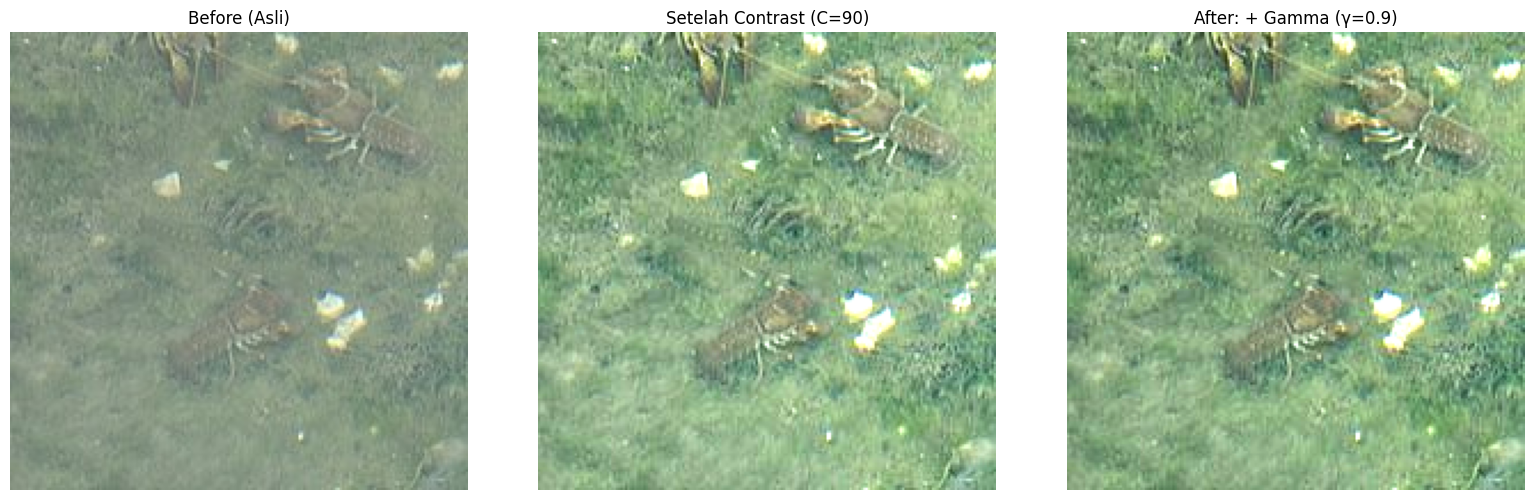

In [48]:
crayfish = cv.imread('/content/drive/MyDrive/Data Saya/semester 5/pengelolahan citra dan visi komputer/udang.jpg')

# naikkan kontras karena citra asli terlihat pudar/low-contrast (kabut air)
C_best = 90
crayfish_contrast = contrast_transform(crayfish, C_best, brightness=5)

# gamma correction ringan untuk menyeimbangkan brightness setelah contrast stretching
gamma_best = 0.9
crayfish_final = gamma_correction(crayfish_contrast, gamma_best)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv.cvtColor(crayfish, cv.COLOR_BGR2RGB)); axes[0].set_title('Before (Asli)')
axes[1].imshow(cv.cvtColor(crayfish_contrast, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Setelah Contrast (C={C_best})')
axes[2].imshow(cv.cvtColor(crayfish_final, cv.COLOR_BGR2RGB)); axes[2].set_title(f'After: + Gamma (γ={gamma_best})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

**Penjelasan**

**Metode yang dipilih** adalah kombinasi **Transformasi Contrast** (untuk melebarkan histogram yang sempit
  akibat efek kabut/scattering cahaya di air) diikuti **Gamma Correction** ringan (untuk menyeimbangkan
  kembali brightness keseluruhan setelah kontras dinaikkan).
**Alasan pemilihan** yaitu karena citra bawah air umumnya memiliki kontras rendah (histogram sempit) akibat
  hamburan cahaya oleh partikel air, sehingga objek (lobster) sulit dibedakan dari latar.
  Contrast transform efektif melebarkan kembali sebaran intensitas tersebut.
**Parameter terbaik (hasil eksperimen)** yaitu nilai kontras C = 90 memberikan pemisahan objek-latar
  paling jelas tanpa menimbulkan artefak clipping berlebihan, gamma γ = 0.9 dipilih agar hasil
  akhir tidak terlalu gelap setelah proses contrast stretching.
**Before-after:** ditunjukkan pada gambar di atas, citra hasil akhir memiliki kontras dan
  kejelasan objek yang jauh lebih baik dibanding citra asli yang pudar/berkabut.
